An Attempt of Training A Dual Stream ViT Segmenter from Scratch

In [1]:
# ==============================================================
# Dual-Stream SegFormer-style ViT (RGB + Thermal)  — FULL PIPELINE
# ==============================================================

import math, os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from einops import rearrange
from transformers import ViTModel, ViTConfig
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import transforms
from PIL import Image
import skimage.io as io
import cv2
from pycocotools import coco, mask as maskUtils

# ----------------------------------------------------------------------
# 1.  DATASET  ──────────────────────────────────────────────────────────
# ----------------------------------------------------------------------
def coco_ann_to_mask(ann, h, w):
    seg = ann.get('segmentation', None)
    if not seg: return np.zeros((h, w), np.uint8)
    rle = maskUtils.merge(maskUtils.frPyObjects(seg, h, w)) if isinstance(seg, list) else seg
    return maskUtils.decode(rle)

def build_aau_dataset(rgb_gt, th_gt, target=(224,224), max_imgs=2197):
    rgb_tf = transforms.Compose([
        transforms.ToPILImage(), transforms.RandomHorizontalFlip(0.5),
        transforms.Resize(target), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)])
    th_tf  = transforms.Compose([
        transforms.ToPILImage(), transforms.RandomHorizontalFlip(0.5),
        transforms.Resize(target), transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])])
    data=[]
    for i in range(max_imgs):
        ann_ids = rgb_gt.getAnnIds(imgIds=[i]); anns = rgb_gt.loadAnns(ann_ids)
        if not anns: continue
        rgb_np = io.imread(rgb_gt.loadImgs([i])[0]['file_name'])
        th_np  = io.imread(th_gt .loadImgs([i])[0]['file_name'])
        if rgb_np.ndim==3 and rgb_np.shape[2]==4:                     # strip alpha
            rgb_np = cv2.cvtColor(rgb_np, cv2.COLOR_RGBA2RGB)
        if th_np.ndim==3: th_np = cv2.cvtColor(th_np, cv2.COLOR_BGR2GRAY)
        h,w=rgb_np.shape[:2]; mask=np.zeros((h,w),np.uint8)
        for a in anns: mask=np.maximum(mask, coco_ann_to_mask(a,h,w)*a['category_id'])
        data.append({
            'rgb': rgb_tf(rgb_np),
            'thermal': th_tf(th_np),
            'mask': torch.from_numpy(np.array(
                transforms.Resize(target, interpolation=Image.NEAREST)(Image.fromarray(mask))
            )).long()
        })
    print("Dataset size:", len(data)); return data

class AAUDataset(Dataset):
    def __init__(self,d): self.d=d
    def __len__(self): return len(self.d)
    def __getitem__(self,i): return self.d[i]

# ----------------------------------------------------------------------
# 2.  LOSSES  ───────────────────────────────────────────────────────────
# ----------------------------------------------------------------------
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6): super().__init__(); self.eps=eps
    def forward(self, logit, tgt):
        prob = torch.softmax(logit,1)
        tgt1 = F.one_hot(tgt, logit.size(1)).permute(0,3,1,2).float()
        inter=(prob*tgt1).sum((0,2,3))
        union=(prob+tgt1).sum((0,2,3))
        dice = (2*inter + self.eps) / (union + self.eps)   # FIX A
        return 1 - dice.mean()                             # scalar now ✅

class FocalLoss(nn.Module):
    def __init__(self,gamma=2,ignore=0): super().__init__(); self.g,self.ign=gamma,ignore
    def forward(self,l,t):
        ce=F.cross_entropy(l,t,reduction='none',ignore_index=self.ign)
        pt=torch.exp(-ce); foc=((1-pt)**self.g)*ce
        mask=(t!=self.ign).float(); return (foc*mask).sum()/mask.sum()

def total_loss(l,t): return F.cross_entropy(l,t,ignore_index=0)+0.5*DiceLoss()(l,t)+0.5*FocalLoss()(l,t)

# ----------------------------------------------------------------------
# 3.  MODEL  ────────────────────────────────────────────────────────────
# ----------------------------------------------------------------------
class CrossAttention(nn.Module):
    def __init__(self,dim,heads=4):
        super().__init__(); self.h=heads; self.scale=(dim//heads)**-0.5
        self.qkv=nn.Linear(dim,dim*3,bias=False); self.proj=nn.Linear(dim,dim)
    def forward(self,q,kv):
        B,N,D=q.shape; h=self.h
        qkv=self.qkv(torch.cat([q,kv],0)).chunk(3,-1)
        q,k,v=qkv[0][:B],qkv[1][B:],qkv[2][B:]
        q,k,v=map(lambda t: rearrange(t,'b n (h d)->b h n d',h=h),(q,k,v))
        att=(q@k.transpose(-2,-1))*self.scale
        x=(att.softmax(-1)@v); x=rearrange(x,'b h n d->b n (h d)')
        return self.proj(x)

class TransformerDecoder(nn.Module):
    def __init__(self, in_dims, embed_dim=256, num_classes=2, num_heads=4):
        super().__init__()
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(d, embed_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(embed_dim),
                nn.ReLU(True)
            ) for d in in_dims
        ])

        self.transformers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim*4)
            for _ in in_dims
        ])

        self.fuse = nn.Sequential(
            nn.Conv2d(embed_dim * len(in_dims), embed_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(True)
        )

        self.head = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, embed_dim, 2, stride=2, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(),
            nn.ConvTranspose2d(embed_dim, num_classes, 4, stride=4)
        )

    def forward(self, feats):  # coarse → fine
        H, W = feats[-1].shape[-2:]
        fused_feats = []
        for f, proj, trans in zip(feats, self.proj, self.transformers):
            f = proj(f)  # [B, C, H, W]
            B, C, h, w = f.shape
            tokens = f.flatten(2).permute(2, 0, 1)  # [HW, B, C]
            encoded = trans(tokens).permute(1, 2, 0).reshape(B, C, h, w)
            upsampled = F.interpolate(encoded, size=(H, W), mode='bilinear', align_corners=False)
            fused_feats.append(upsampled)

        x = self.fuse(torch.cat(fused_feats, dim=1))
        return self.head(x)

class MLPDecoder(nn.Module):
    def __init__(self,in_dims,emb=256,n_cls=2):
        super().__init__()
        self.proj=nn.ModuleList([nn.Sequential(
            nn.Conv2d(d,emb,1,bias=False),nn.BatchNorm2d(emb),nn.ReLU(True)) for d in in_dims])
        self.fuse=nn.Sequential(nn.Conv2d(emb*4,emb,1,bias=False),
                                 nn.BatchNorm2d(emb),nn.ReLU(True))
        self.head=nn.Sequential(nn.ConvTranspose2d(emb,emb,2,2,bias=False),
                                 nn.BatchNorm2d(emb),nn.ReLU(True),
                                 nn.ConvTranspose2d(emb,n_cls,4,4))
    def forward(self,feats):           # feats coarse→fine
        H,W=feats[-1].shape[-2:]
        up=[F.interpolate(p(f),(H,W),mode='bilinear',align_corners=False)
            for f,p in zip(feats,self.proj)]
        x=self.fuse(torch.cat(up,1)); return self.head(x)  # B×C×112×112

class DualStreamSegFormer(nn.Module):
    def __init__(self, n_cls, vit='google/vit-base-patch16-224'):
        super().__init__()
        self.rgb = ViTModel.from_pretrained(vit, output_hidden_states=True)
        cfg = self.rgb.config; D = cfg.hidden_size
        therm_cfg = ViTConfig(**cfg.to_dict()); therm_cfg.num_channels = 1
        therm_cfg.output_hidden_states = True; therm_cfg.add_pooling_layer = False
        self.tir = ViTModel(therm_cfg)
        self.tir.embeddings.patch_embeddings.projection = nn.Conv2d(1, D, 16, 16)
        self.layers = [2, 5, 8, 11]
        self.xattn = nn.ModuleList([CrossAttention(D) for _ in self.layers])
        self.lin = nn.ModuleList([nn.Sequential(nn.Linear(D, D), nn.BatchNorm1d(D), nn.ReLU(True)) for _ in self.layers])
        self.gates = nn.ModuleList([nn.Linear(D, D) for _ in self.layers])
        self.pos = nn.ParameterList([
            nn.Parameter(torch.randn(1, (cfg.image_size // 16)**2, D)) for _ in self.layers
        ])
        self.dec = MLPDecoder([D] * 4, emb=256, n_cls=n_cls)
        self.refine = nn.Sequential(
            nn.Conv2d(n_cls, n_cls, 3, padding=1),
            nn.BatchNorm2d(n_cls),
            nn.ReLU(),
            nn.Conv2d(n_cls, n_cls, 1)
        )

    def tokens2map(self, t, B, idx):
        P = t.size(1); H = int(math.sqrt(P)); D = t.size(2)
        t = self.lin[idx](t.view(-1, D)).view(B, -1, D)
        return t.transpose(1, 2).reshape(B, D, H, H)

    def forward(self, rgb, th):
        B = rgb.size(0); feats = []
        r_h = self.rgb(rgb).hidden_states; t_h = self.tir(th).hidden_states
        for i, ly in enumerate(self.layers):
            tr, tt = r_h[ly][:, 1:], t_h[ly][:, 1:]  # remove CLS
            fr = self.xattn[i](tr, tt); ft = self.xattn[i](tt, tr)
            gate = torch.sigmoid(self.gates[i](tr - tt))
            fused = gate * fr + (1 - gate) * ft + tr + tt
            fused = fused + self.pos[i].expand(B, -1, -1)
            feats.append(self.tokens2map(fused, B, i))

        logits = self.dec(feats[::-1])  # 112×112
        logits = F.interpolate(logits, size=rgb.shape[-2:], mode='bilinear', align_corners=False)  # 224×224
        logits = self.refine(logits)
        return logits


# ----------------------------------------------------------------------
# 4.  TRAIN LOOP  ───────────────────────────────────────────────────────
# ----------------------------------------------------------------------
def run_phase(model,epochs,tr_ld,va_ld,device,phase):
    if phase==0:
        params=[{'params': list(model.dec.parameters())+
                            list(model.lin.parameters())+
                            list(model.xattn.parameters()), 'lr':1e-3}]
    elif phase==1:
        params=[{'params': model.tir.parameters(),'lr':1e-4},
                {'params': list(model.dec.parameters())+
                            list(model.lin.parameters())+
                            list(model.xattn.parameters()), 'lr':5e-4}]
    else:
        params=[{'params': model.rgb.parameters(),'lr':1e-5},
                {'params': model.tir.parameters(),'lr':1e-5},
                {'params': list(model.dec.parameters())+
                            list(model.lin.parameters())+
                            list(model.xattn.parameters()), 'lr':5e-4}]
    opt=torch.optim.AdamW(params, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda ep: (1 - ep / epochs)**0.9)
    # sched=OneCycleLR(opt,max_lr=[g['lr'] for g in opt.param_groups],
    #                  steps_per_epoch=len(tr_ld),epochs=epochs,
    #                  div_factor=25.,final_div_factor=1e4,pct_start=.3)
    for ep in range(1,epochs+1):
        model.train(); tl=0
        for b in tr_ld:
            rgb,th,m=(b[k].to(device) for k in ['rgb','thermal','mask'])
            opt.zero_grad(); out=model(rgb,th); loss=total_loss(out,m)
            loss.backward(); opt.step(); sched.step(); tl+=loss.item()*rgb.size(0)
        tl/=len(tr_ld.dataset)
        model.eval(); vl,corr,tot=0,0,0
        with torch.no_grad():
            for b in va_ld:
                rgb,th,m=(b[k].to(device) for k in ['rgb','thermal','mask'])
                out=model(rgb,th); vl+=total_loss(out,m).item()*rgb.size(0)
                p=out.argmax(1); v=m!=0; corr+=(p[v]==m[v]).sum().item(); tot+=v.sum().item()
        vl/=len(va_ld.dataset); acc=corr/tot
        print(f"[P{phase} E{ep}/{epochs}] train {tl:.3f} | val {vl:.3f} | acc {acc:.3f}")

# ----------------------------------------------------------------------
# 5.  RUN  ──────────────────────────────────────────────────────────────
# ----------------------------------------------------------------------
if __name__ == "__main__":
    rgb_json, th_json = './aauRainSnow-rgb.json', './aauRainSnow-thermal.json'
    rgb_gt, th_gt = coco.COCO(rgb_json), coco.COCO(th_json)

    data=build_aau_dataset(rgb_gt, th_gt, target=(224,224), max_imgs=2197)
    ds=AAUDataset(data); n=len(ds); tr=int(.7*n); va=int(.15*n); te=n-tr-va
    tr_ds,va_ds,te_ds=random_split(ds,[tr,va,te])
    tr_ld=DataLoader(tr_ds,8,True); va_ld=DataLoader(va_ds,8)
    num_cls=max(rgb_gt.getCatIds())+1
    device='cuda' if torch.cuda.is_available() else 'cpu'
    model=DualStreamSegFormer(num_cls).to(device)

    for p,e in enumerate([5,5,10]): run_phase(model,e,tr_ld,va_ld,device,p)

    torch.save(model.state_dict(),'dualstream_segformer_6.pth')


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
Dataset size: 2029


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[P0 E1/5] train 4.118 | val 4.289 | acc 0.582
[P0 E2/5] train 2.951 | val 2.940 | acc 0.702
[P0 E3/5] train 2.384 | val 2.441 | acc 0.734
[P0 E4/5] train 1.938 | val 2.155 | acc 0.763
[P0 E5/5] train 1.583 | val 2.082 | acc 0.768
[P1 E1/5] train 1.668 | val 2.228 | acc 0.755
[P1 E2/5] train 2.270 | val 2.952 | acc 0.714
[P1 E3/5] train 2.107 | val 3.072 | acc 0.443
[P1 E4/5] train 1.747 | val 2.208 | acc 0.785
[P1 E5/5] train 1.397 | val 1.990 | acc 0.819
[P2 E1/10] train 1.324 | val 2.165 | acc 0.800
[P2 E2/10] train 1.488 | val 2.554 | acc 0.716
[P2 E3/10] train 1.653 | val 4.416 | acc 0.617
[P2 E4/10] train 1.581 | val 2.256 | acc 0.821
[P2 E5/10] train 1.342 | val 1.632 | acc 0.821
[P2 E6/10] train 1.193 | val 2.211 | acc 0.815
[P2 E7/10] train 1.063 | val 2.024 | acc 0.830
[P2 E8/10] train 0.914 | val 1.761 | acc 0.845
[P2 E9/10] train 0.818 | val 1.889 | acc 0.836
[P2 E10/10] train 0.783 | val 1.970 | acc 0.833


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03235293924808502..1.000000011920929].


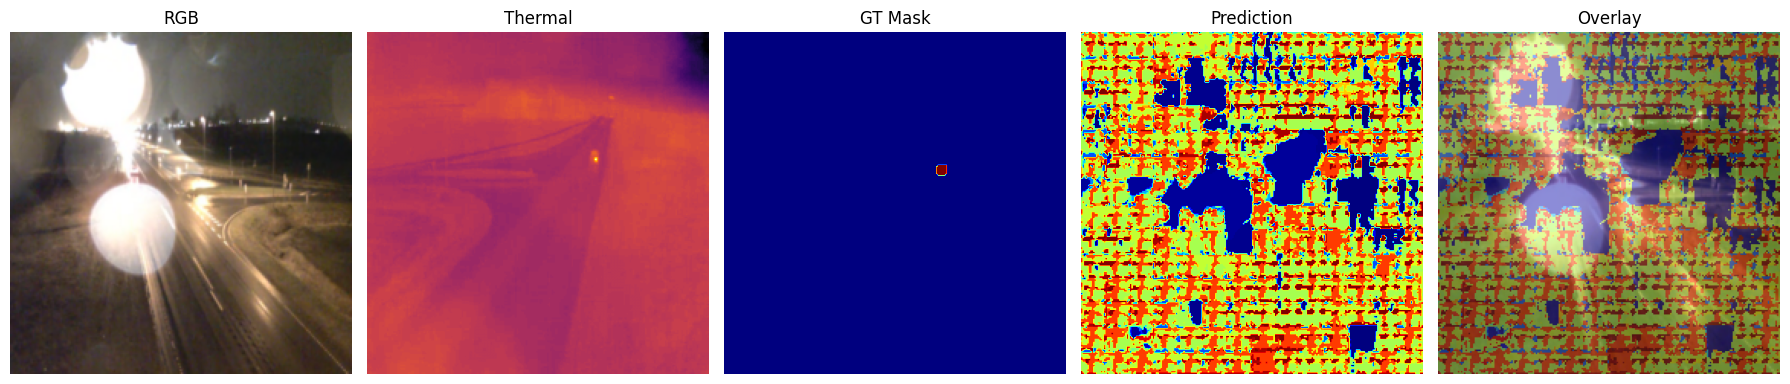

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms.functional as TF

# --------------------------------------------------------------
#  visualize_sample : quick qualitative sanity-check
# --------------------------------------------------------------
def visualize_sample(sample, model, device, class_cmap='jet', alpha=0.45):
    """
    sample : dict from AAUDataset  {rgb, thermal, mask}
    model  : DualStreamSegFormer (already .eval()'d & on device)
    device : torch.device('cuda'|'cpu')
    class_cmap : matplotlib cmap for masks
    alpha  : overlay transparency
    """
    model.eval()
    rgb = sample['rgb'].unsqueeze(0).to(device)      # 1×3×224×224
    th  = sample['thermal'].unsqueeze(0).to(device)  # 1×1×224×224
    with torch.no_grad():
        logits = model(rgb, th)                      # 1×C×224×224
        pred   = logits.argmax(1).squeeze().cpu().numpy()

    gt  = sample['mask'].cpu().numpy()
    rgb_img = (rgb.squeeze().cpu()*0.5 + 0.5).permute(1,2,0).numpy()  # un-norm
    th_img  = th.squeeze().cpu().numpy()

    # build overlay
    cmap = plt.get_cmap(class_cmap)
    pred_rgb = cmap(pred / pred.max())[:, :, :3]     # drop alpha
    overlay = (1-alpha)*rgb_img + alpha*pred_rgb

    # plot
    fig, ax = plt.subplots(1, 5, figsize=(18,4))
    ax[0].imshow(rgb_img);           ax[0].set_title('RGB');          ax[0].axis('off')
    ax[1].imshow(th_img, cmap='inferno'); ax[1].set_title('Thermal'); ax[1].axis('off')
    ax[2].imshow(gt, cmap=class_cmap);    ax[2].set_title('GT Mask');  ax[2].axis('off')
    ax[3].imshow(pred, cmap=class_cmap);  ax[3].set_title('Prediction'); ax[3].axis('off')
    ax[4].imshow(overlay);           ax[4].set_title('Overlay');      ax[4].axis('off')
    plt.tight_layout(); plt.show()

# -----------------------------------------------------------------
# Example usage (after training):
# -----------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load('dualstream_segformer_6.pth', map_location=device))
model.to(device).eval()

sample = te_ds.dataset[19]      # any index from your test split
visualize_sample(sample, model, device)


In [9]:
# ----------------------------------------------------------------------
# 6.  TEST ACCURACY  ────────────────────────────────────────────────────
# ----------------------------------------------------------------------
def test_model_accuracy(model, test_loader, device):
    """
    Computes pixel‐accuracy *on mask != 0* over the entire test set.
    """
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for batch in test_loader:
            rgb     = batch['rgb'].to(device)
            thermal = batch['thermal'].to(device)
            mask    = batch['mask'].to(device)

            logits = model(rgb, thermal)        # (B, C, H, W)
            preds  = logits.argmax(dim=1)       # (B, H, W)

            valid  = mask != 0                  # ignore background
            correct += (preds[valid] == mask[valid]).sum().item()
            total   += valid.sum().item()

    acc = correct / total if total > 0 else 0.0
    print(f"\nTest set pixel‐accuracy (mask!=0): {acc:.4f} ({correct}/{total})")
    return acc

# ─── example usage ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load('dualstream_segformer_final.pth', map_location=device))
model.to(device).eval()
te_ld = DataLoader(te_ds, 8)

test_acc = test_model_accuracy(model, te_ld, device)



Test set pixel‐accuracy (mask!=0): 0.8721 (322512/369827)
